# Pipeline Final — Predição de Alfabetização

Este notebook contém a **pipeline final, limpa e reproduzível** do projeto, usando as funções modularizadas em `src/`.

Para o raciocínio completo por trás de cada decisão (por que cada coluna foi removida, as investigações de nulos, a comparação de 4 modelos, SHAP, etc.), ver `notebooks/eda.ipynb` — este notebook é o resultado consolidado daquele processo, não um substituto dele.


In [1]:
import sys
sys.path.append("../src")

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

from preprocessing.preparar_dados import (
    filtrar_escopo_modelagem,
    remover_colunas_leakage,
    remover_multicolinearidade,
    tratar_meta_municipio_ausente,
    preparar_features,
    COLUNAS_NUMERICAS_PARA_PADRONIZAR,
)
from evaluation.avaliar_modelo import avaliar_modelo, comparar_recall_com_sem_balanceamento
from visualization.graficos import plot_matriz_confusao, plot_importancia_features


## 1. Carregamento e pré-processamento

In [2]:
df = pd.read_parquet("../data/gold/alunos_alfabetizacao.parquet")
print("Shape inicial:", df.shape)


Shape inicial: (1747439, 43)


In [3]:
df_modelagem = filtrar_escopo_modelagem(df)
df_modelagem = remover_colunas_leakage(df_modelagem)
df_modelagem = remover_multicolinearidade(df_modelagem)
df_modelagem = tratar_meta_municipio_ausente(df_modelagem)

print("Shape após pré-processamento:", df_modelagem.shape)


Shape após pré-processamento: (1503058, 29)


In [4]:
X, y, label_encoder = preparar_features(df_modelagem)

print("X:", X.shape)
print("y:", y.shape)
print("Classes:", label_encoder.classes_)


X: (1501374, 37)
y: (1501374,)
Classes: ['Não' 'Sim']


## 2. Separação treino/teste

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

print("Treino:", X_train.shape)
print("Teste:", X_test.shape)


Treino: (1201099, 37)
Teste: (300275, 37)


## 3. Pipeline do modelo

Integra o pré-processamento numérico (`StandardScaler`, aplicado só nas colunas numéricas via `ColumnTransformer`) diretamente ao modelo (`RandomForestClassifier`), num único objeto `Pipeline`.

Hiperparâmetros (`n_estimators=50`, `max_depth=10`) já otimizados via `RandomizedSearchCV` com validação cruzada (ver `notebooks/eda.ipynb` para o processo completo de busca).


In [6]:
colunas_numericas = [c for c in COLUNAS_NUMERICAS_PARA_PADRONIZAR if c in X_train.columns]

pre_processador = ColumnTransformer(
    transformers=[("scaler", StandardScaler(), colunas_numericas)],
    remainder="passthrough",
)

pipeline_final = Pipeline([
    ("pre_processamento", pre_processador),
    ("modelo", RandomForestClassifier(
        n_estimators=50, max_depth=10,
        class_weight="balanced", random_state=42, n_jobs=-1,
    )),
])

pipeline_final.fit(X_train, y_train)
print("Pipeline treinado com sucesso")


Pipeline treinado com sucesso


## 4. Avaliação

In [7]:
resultado = avaliar_modelo(pipeline_final, X_test, y_test)

print(f"Acurácia: {resultado['acuracia']:.4f}")
print()
print(resultado["relatorio"])


Acurácia: 0.6251

              precision    recall  f1-score   support

         Não       0.54      0.66      0.60    125015
         Sim       0.71      0.60      0.65    175260

    accuracy                           0.63    300275
   macro avg       0.63      0.63      0.62    300275
weighted avg       0.64      0.63      0.63    300275



<Axes: title={'center': 'Pipeline Final - Random Forest Balanceada'}, xlabel='Valor previsto', ylabel='Valor real'>

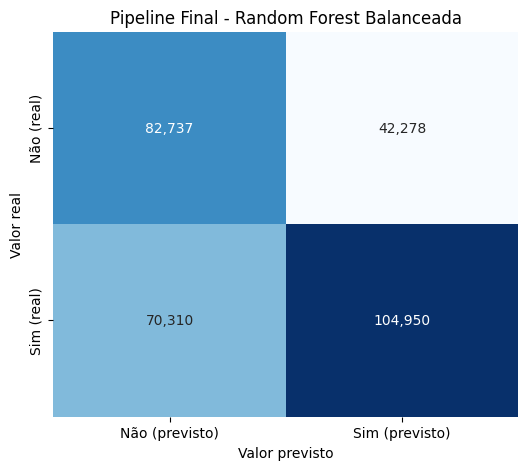

In [8]:
plot_matriz_confusao(resultado["matriz_confusao"], titulo="Pipeline Final - Random Forest Balanceada")


**Nota**: acurácia (~62%) é consciente e inferior à obtida sem balanceamento de classe (~65%) — trade-off documentado em `notebooks/eda.ipynb`, priorizando recall da classe de risco ("Não alfabetizado") sobre acurácia geral, dado o objetivo de identificação de risco educacional.

## 5. Importância das features

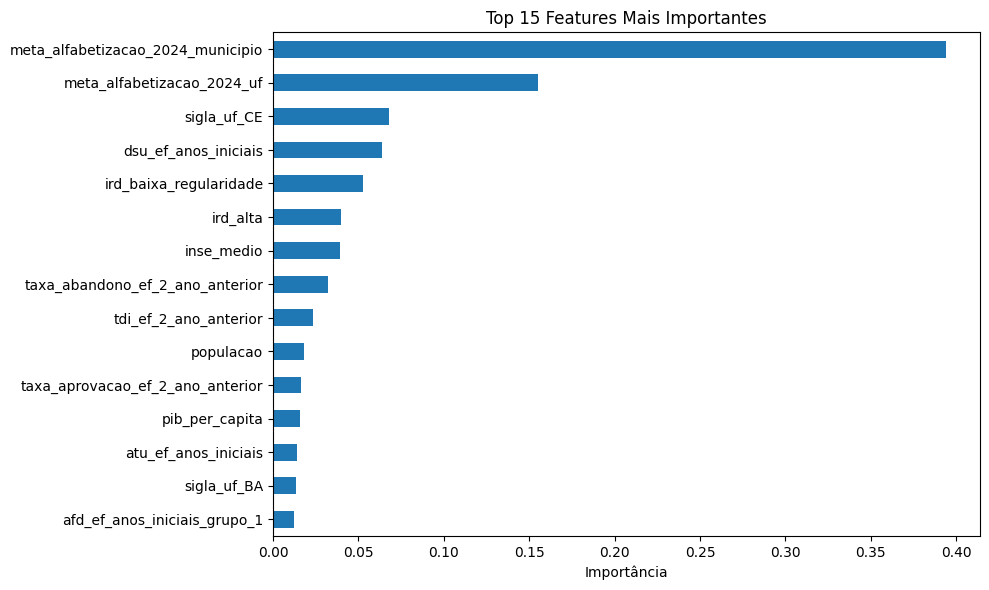

In [9]:
nomes_features = pipeline_final.named_steps["pre_processamento"].get_feature_names_out()
nomes_features = [n.split("__")[-1] for n in nomes_features]  # remove prefixo técnico do ColumnTransformer

importancias = plot_importancia_features(
    pipeline_final.named_steps["modelo"],
    nomes_features,
    top_n=15,
    titulo="Top 15 Features Mais Importantes",
)
